### Explicación del dataset

FashionMNIST es un dataset de imágenes en blanco y negro (escala de grises) que representa prendas de ropa

### Carga del dataset

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

# Definimos las transformaciones que se aplican a las imágenes
transform = transforms.Compose([
    transforms.ToTensor()  # Convierte las imágenes a tensores
])

# Cargamos el dataset FashionMNIST de entrenamiento
trainset = torchvision.datasets.FashionMNIST(
    root='./data',   # carpeta donde se guardan los datos
    train=True,      # conjunto de entrenamiento
    download=True,   # descarga el dataset si no existe
    transform=transform
)

# Cargamos el dataset FashionMNIST de test
testset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=False,     # conjunto de prueba
    download=True,
    transform=transform
)

# Tamaño de los lotes (cuántas imágenes se procesan a la vez)
batch_size = 32

# DataLoader del entrenamiento (mezcla los datos)
trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=batch_size,
    shuffle=True
)

# DataLoader del test (no se mezcla)
testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=batch_size,
    shuffle=False
)

### Clase del modelo

In [10]:
import torch
import torch.nn as nn

# Definimos una red neuronal convolucional para FashionMNIST
class FashionMNISTModel(nn.Module):
    def __init__(self):
        super().__init__()

        # Primera capa convolucional
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.act1 = nn.ReLU()            # activación
        self.drop1 = nn.Dropout(0.3)     # evita sobreajuste
        self.pool1 = nn.MaxPool2d(2, 2)  # reduce tamaño a la mitad

        # Segunda capa convolucional
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1)
        self.act2 = nn.ReLU()
        self.drop2 = nn.Dropout(0.3)
        self.pool2 = nn.MaxPool2d(2, 2)

        # Aplanar la imagen para la parte final
        self.flat = nn.Flatten()

        # 32 mapas de 7x7 = 1568 valores
        self.fc3 = nn.Linear(1568, 512)
        self.act3 = nn.ReLU()
        self.drop3 = nn.Dropout(0.5)

        # Capa final: 10 clases (FashionMNIST tiene 10 categorías)
        self.fc4 = nn.Linear(512, 10)

    def forward(self, x):

        # Pasamos por la primera convolución + activación + pooling
        x = self.act1(self.conv1(x))
        x = self.drop1(x)
        x = self.pool1(x)

        # Segunda convolución + activación + pooling
        x = self.act2(self.conv2(x))
        x = self.drop2(x)
        x = self.pool2(x)

        # Convertimos la imagen en un vector
        x = self.flat(x)

        # Capa densa intermedia
        x = self.act3(self.fc3(x))
        x = self.drop3(x)

        # Capa de salida (predicción final)
        x = self.fc4(x)

        return x

### Entrenamiento del dataset

In [11]:
model = FashionMNISTModel()
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
model.to(device)

n_epochs = 10
for epoch in range(n_epochs):
    for inputs, labels in trainloader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        y_pred = model(inputs)
        loss = loss_fn(y_pred, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    acc = 0
    count = 0
    for inputs, labels in testloader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        y_pred = model(inputs)
        acc += (torch.argmax(y_pred, 1) == labels).float().sum()
        count += len(labels)
    acc = acc/count
    print("Época %d: accuracy del modelo %.2f%%" % (epoch, acc*100))

torch.save(model.state_dict(), 'fashionmnist_model.pth')

cpu
Época 0: accuracy del modelo 83.42%
Época 1: accuracy del modelo 85.25%
Época 2: accuracy del modelo 87.25%
Época 3: accuracy del modelo 88.04%
Época 4: accuracy del modelo 88.86%
Época 5: accuracy del modelo 89.11%
Época 6: accuracy del modelo 89.87%
Época 7: accuracy del modelo 89.86%
Época 8: accuracy del modelo 89.81%
Época 9: accuracy del modelo 89.77%


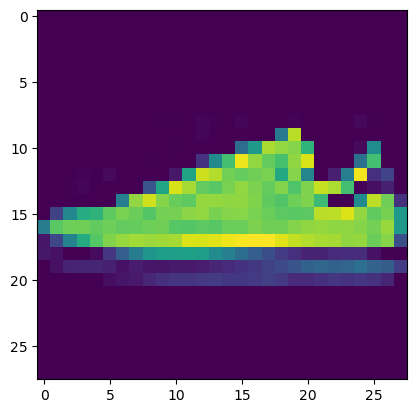

In [15]:
import matplotlib.pyplot as plt

model.load_state_dict(torch.load('fashionmnist_model.pth'))

plt.imshow(trainset.data[6])
plt.show()

In [16]:
import torch

# coger una imagen
X, label = trainset[6]

# añadir dimensión batch (1, 1, 28, 28)
X = X.unsqueeze(0)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model.eval()
model = model.to(device)
X = X.to(device)

with torch.no_grad():
    y_pred = model(X)
    pred = torch.argmax(y_pred, dim=1)

print("Etiqueta real:", label)
print("Predicción:", pred.item())

Etiqueta real: 7
Predicción: 7


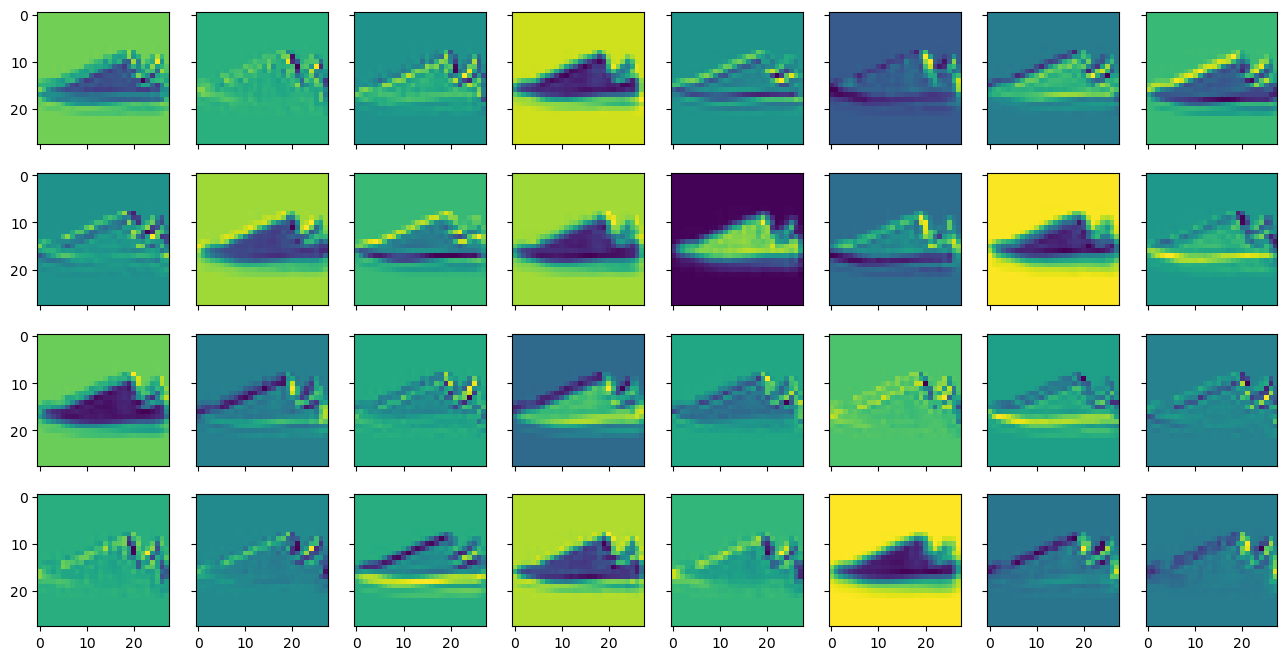

In [17]:
# Desactivamos el cálculo de gradientes (solo visualización)
with torch.no_grad():
    
    # Pasamos la imagen por la primera capa convolucional
    feature_maps = model.conv1(X.to(device))

# Creamos una cuadrícula para mostrar los 32 mapas de características
fig, ax = plt.subplots(4, 8, sharex=True, sharey=True, figsize=(16, 8))

# Recorremos los 32 feature maps
for i in range(0, 32):
    
    # Calculamos fila y columna en la cuadrícula
    row, col = i // 8, i % 8
    
    # Mostramos cada mapa de características
    ax[row][col].imshow(feature_maps[0][i].cpu().numpy())

# Mostramos la figura
plt.show()

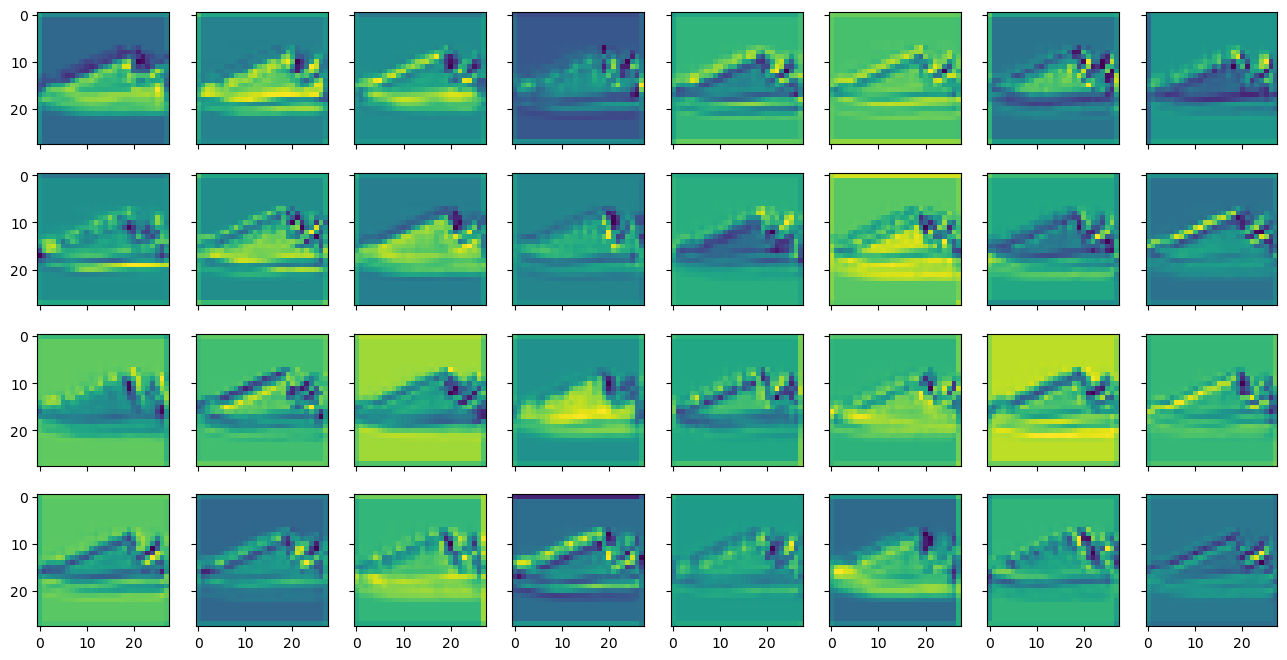

In [19]:
# Desactivamos gradientes porque solo queremos visualizar
with torch.no_grad():

    # Primera convolución (extrae patrones básicos)
    feature_maps = model.conv1(X.to(device))
    
    # Aplicamos activación (ReLU)
    feature_maps = model.act1(feature_maps)
    
    # Dropout (apaga neuronas aleatoriamente)
    feature_maps = model.drop1(feature_maps)
    
    # Segunda convolución (patrones más complejos)
    feature_maps = model.conv2(feature_maps)

# Creamos una cuadrícula para visualizar los 32 mapas
fig, ax = plt.subplots(4, 8, sharex=True, sharey=True, figsize=(16, 8))

# Recorremos los 32 feature maps
for i in range(0, 32):

    # Calculamos posición en la cuadrícula
    row, col = i // 8, i % 8

    # Mostramos cada mapa de características
    ax[row][col].imshow(feature_maps[0][i].cpu().numpy())

# Mostramos la figura
plt.show()